# ESM-C layer sweep: vilip1 composite-hotspot design campaign

Sweeps HDBSCAN clustering quality across all 31 ESM-C hidden-state layers (`layer_0` = embedding output before any transformer block, `layer_30` = final layer) on the same filtered pool, using the same HDBSCAN params already tuned on vilip1's original full-campaign pool (`min_cluster_size=4`, `min_samples=3`) -- held fixed across layers here so the sweep isolates the effect of layer depth, not re-tuned HDBSCAN parameters.

This campaign (`vilip1-design-composite_hotspot-20260724-v2`) is a different design run than `vilip1_full20k`: 5000 designs (not 20000) targeting a composite hotspot epitope on the same vilip1 target, via Boltz's protein-design job `vilip1-design-composite_hotspot-20260724-v2`.

Goal: figure out whether embedding usefulness for clustering scales monotonically with depth or peaks somewhere in the middle, before spending time on the full UMAP/medoid/wet-lab-selection/structural-overlay pipeline on any particular layer.

Embeddings computed via `inference/embed_esmc.py --layers all` on Waluigi (one forward pass per batch; every hidden_states layer pooled from the same pass).

In [1]:
import os
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

## Filter to well-scored designs (same as final-layer notebook)

In [3]:
# vilip1_full20k's exact thresholds (iptm>0.7, ipsae>0.7, ipae<6.0) only
# passed 58/5000 designs here -- too small a pool for a useful clustering
# analysis. Loosened ipsae/ipae (keeping iptm's bar the same) to get a
# larger, still reasonably well-scored pool -- see manifest_with_ipsae.csv
# threshold-grid search for how these were picked (591/5000 pass).

# NOTE: this notebook lives at notebooks/bridget/esmc_embedding_analysis/ --
# three directories deep from the repo root, so data paths need ../../../.
MANIFEST_PATH = "../../../data/vilip1-design-composite_hotspot-20260724-v2/manifest_with_ipsae.csv"
EMBEDDINGS_PATH = "../../../data/vilip1-design-composite_hotspot-20260724-v2/embeddings_all_layers.npz"
# Sweep outputs land in a layer_sweep/ subfolder so they don't clobber the
# final-layer analysis files already in clustering/.
OUTPUT_DIR = "../../../data/vilip1-design-composite_hotspot-20260724-v2/clustering/layer_sweep"
os.makedirs(OUTPUT_DIR, exist_ok=True)

manifest = pd.read_csv(MANIFEST_PATH)

IPTM_MIN = 0.7
IPSAE_MIN = 0.4
IPAE_MAX = 10.0

filtered_manifest = manifest[
    (manifest["iptm"] > IPTM_MIN)
    & (manifest["ipsae"] > IPSAE_MIN)
    & (manifest["ipae"] < IPAE_MAX)
].copy()

print(
    f"{len(filtered_manifest)}/{len(manifest)} designs pass " + f"iptm>{IPTM_MIN}, ipsae>{IPSAE_MIN}, ipae<{IPAE_MAX}"
)

filtered_ids = set(filtered_manifest["id"])


591/5000 designs pass iptm>0.7, ipsae>0.4, ipae<10.0


## Load all-layer embeddings, restrict to filtered pool

In [4]:
npz = np.load(EMBEDDINGS_PATH, allow_pickle=True)
all_ids = npz["ids"]
keep_mask = np.array([eid in filtered_ids for eid in all_ids])
protein_names = all_ids[keep_mask].tolist()

layer_keys = sorted(
    [k for k in npz.files if k.startswith("layer_")],
    key=lambda k: int(k.split("_")[1]),
)
layer_indices = [int(k.split("_")[1]) for k in layer_keys]
print(f"Loaded {len(all_ids)} embeddings, kept {keep_mask.sum()} after filtering, {len(layer_keys)} layers ({layer_indices[0]}..{layer_indices[-1]})")

# L2-normalize each layer's filtered embeddings up front (HDBSCAN below runs
# euclidean distance, which on unit-norm vectors is equivalent to cosine --
# same convention as esmc_embedding_analysis_vilip1.ipynb).
X_by_layer = {
    idx: normalize(npz[f"layer_{idx}"][keep_mask], norm="l2", axis=1)
    for idx in layer_indices
}

Loaded 5000 embeddings, kept 591 after filtering, 31 layers (0..30)


## Sweep HDBSCAN across every layer

In [5]:
MIN_CLUSTER_SIZE = 4
MIN_SAMPLES = 3

sweep_rows = []
for idx in layer_indices:
    X = X_by_layer[idx]
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean",
        prediction_data=True,
    )
    labels = clusterer.fit_predict(X)

    n_total = len(labels)
    n_noise = int(np.sum(labels == -1))
    unique_clusters = set(labels) - {-1}
    n_clusters = len(unique_clusters)

    non_noise = labels != -1
    if n_clusters >= 2 and non_noise.sum() >= 2:
        sil = silhouette_score(X[non_noise], labels[non_noise], metric="cosine")
    else:
        sil = float("nan")

    sweep_rows.append({
        "layer": idx,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_frac": n_noise / n_total,
        "silhouette": sil,
    })
    print(f"layer {idx:>2}: clusters={n_clusters:>3}  noise={n_noise:>5}/{n_total} ({n_noise/n_total:.1%})  silhouette={sil:.4f}")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(f"{OUTPUT_DIR}/layer_sweep_summary.csv", index=False)
print(f"\nSaved {OUTPUT_DIR}/layer_sweep_summary.csv")

layer  0: clusters=  2  noise=  122/591 (20.6%)  silhouette=0.7270
layer  1: clusters=  3  noise=  246/591 (41.6%)  silhouette=0.6517
layer  2: clusters=  2  noise=  204/591 (34.5%)  silhouette=0.7399
layer  3: clusters=  3  noise=  139/591 (23.5%)  silhouette=0.4671
layer  4: clusters=  3  noise=   95/591 (16.1%)  silhouette=0.4628
layer  5: clusters=  5  noise=  141/591 (23.9%)  silhouette=0.3454
layer  6: clusters=  4  noise=  121/591 (20.5%)  silhouette=0.4284
layer  7: clusters=  2  noise=   56/591 (9.5%)  silhouette=0.6988
layer  8: clusters=  3  noise=  119/591 (20.1%)  silhouette=0.4768
layer  9: clusters=  2  noise=   51/591 (8.6%)  silhouette=0.7040
layer 10: clusters=  3  noise=   77/591 (13.0%)  silhouette=0.4868
layer 11: clusters=  4  noise=   92/591 (15.6%)  silhouette=0.4882
layer 12: clusters=  3  noise=   92/591 (15.6%)  silhouette=0.5396
layer 13: clusters=  3  noise=   82/591 (13.9%)  silhouette=0.5456
layer 14: clusters=  3  noise=   93/591 (15.7%)  silhouette=0.56

## Plot clustering quality vs. layer depth

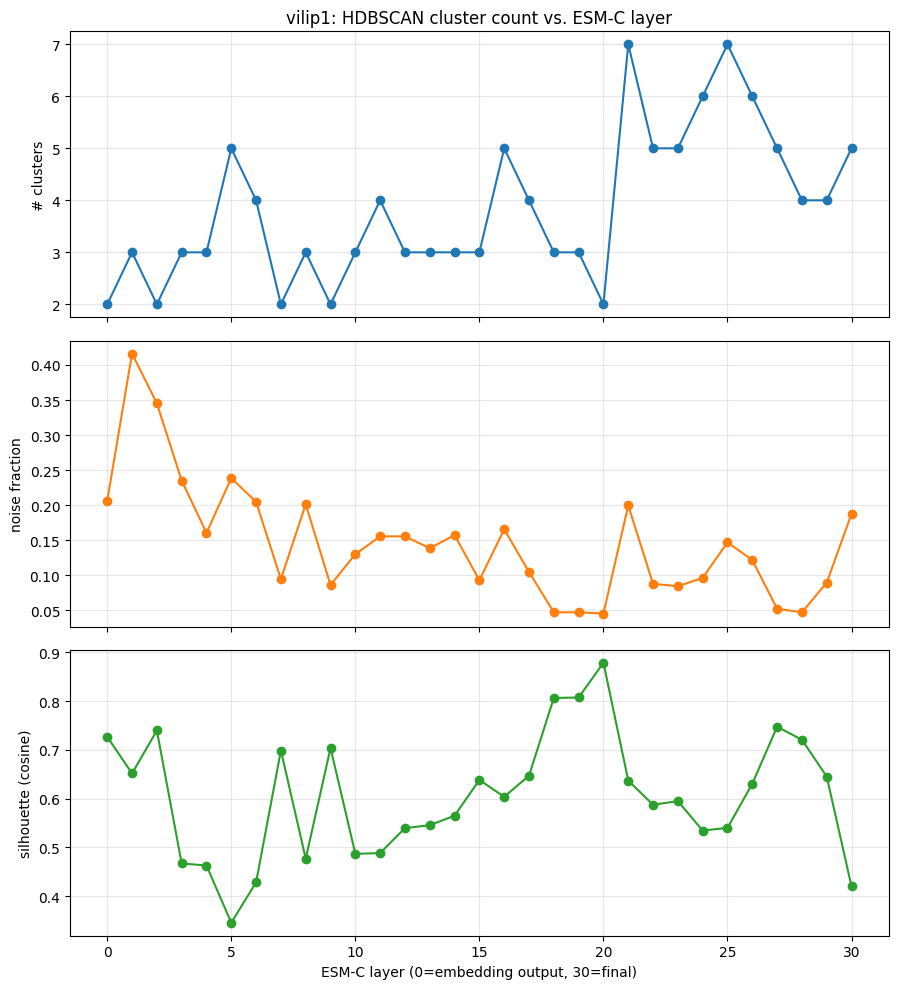

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(sweep_df["layer"], sweep_df["n_clusters"], marker="o")
axes[0].set_ylabel("# clusters")
axes[0].set_title("vilip1: HDBSCAN cluster count vs. ESM-C layer")

axes[1].plot(sweep_df["layer"], sweep_df["noise_frac"], marker="o", color="tab:orange")
axes[1].set_ylabel("noise fraction")

axes[2].plot(sweep_df["layer"], sweep_df["silhouette"], marker="o", color="tab:green")
axes[2].set_ylabel("silhouette (cosine)")
axes[2].set_xlabel("ESM-C layer (0=embedding output, 30=final)")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/layer_sweep.png", dpi=200)
plt.show()

## Candidate layers for the full deep-dive pipeline

In [6]:
# Ranks layers by silhouette among those that actually found >=2 clusters
# without collapsing to mostly noise (noise_frac < 0.5) -- a layer that puts
# everything in one cluster or calls everything noise isn't a useful
# clustering, whatever its silhouette says.
candidates = sweep_df[
    (sweep_df["n_clusters"] >= 2) & (sweep_df["noise_frac"] < 0.5)
].sort_values("silhouette", ascending=False)

print("Top candidate layers by silhouette (n_clusters>=2, noise<50%):")
print(candidates.head(10).to_string(index=False))

print("\nFinal layer (30) for reference:")
print(sweep_df[sweep_df["layer"] == 30].to_string(index=False))

Top candidate layers by silhouette (n_clusters>=2, noise<50%):
 layer  n_clusters  n_noise  noise_frac  silhouette
    20           2       27    0.045685    0.878928
    19           3       28    0.047377    0.807591
    18           3       28    0.047377    0.806565
    27           5       31    0.052453    0.747633
     2           2      204    0.345178    0.739863
     0           2      122    0.206430    0.726968
    28           4       28    0.047377    0.720800
     9           2       51    0.086294    0.704030
     7           2       56    0.094755    0.698788
     1           3      246    0.416244    0.651708

Final layer (30) for reference:
 layer  n_clusters  n_noise  noise_frac  silhouette
    30           5      111    0.187817    0.419868
